In [1]:
import sys, kardemumma
print(sys.executable)         # kernel Python
print(kardemumma.__file__)    # should point to your local repo under src/kardemumma

/home/thanadol/Documents/GitHub/kardemumma/.venv/bin/python
/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/__init__.py


In [2]:
# Load packages
from pathlib import Path
import os
import re
import sys
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# Importantlly, import kardemumma :)
import kardemumma as kdm

In [3]:

# Skyline data path
skyline_path = "data/MARTHA/DE17501_Martha_results_dotp_charge_16042026.csv"

# Import skyline data (includes column "Isotope Label Type" from Precursor)
skyline_importer = kdm.ImportSkylineFile(skyline_path)
skyline_data = skyline_importer.import_skyline_file()

Importing Skyline file: data/MARTHA/DE17501_Martha_results_dotp_charge_16042026.csv
File data/MARTHA/DE17501_Martha_results_dotp_charge_16042026.csv is valid.


In [4]:
# **SDRF**
sdrf_path = 'sdrf/sdrf_MARTHA_combined.sdrf.tsv'

# Valdate sdrf 
# kdm.validate_sdrf(sdrf_path)
kdm.readout_ms_type(sdrf_path)



Type(s) of MS experiment(s) in SDRF: NT=Parallel Reaction Monitoring;AC=MS:1002956


['NT=Parallel Reaction Monitoring;AC=MS:1002956']

In [5]:


sdrf_data = kdm.ImportSDRFFile(sdrf_path)
sdrf_data_file = sdrf_data.import_sdrf_file()

# Find which file is not in the sdrf
print('Sample names in the Skyline file but not in the SDRF file:')
not_in_sdrf = set(skyline_data['File Name']) - set(sdrf_data_file['comment[data file]'])
print(not_in_sdrf)

# Find which file is not in the skyline
print('--------------------------------')
print('Sample names in the SDRF file but not in the Skyline file:')
not_in_skyline = set(sdrf_data_file['comment[data file]']) - set(skyline_data['File Name'])
print(not_in_skyline) # Need to update SDRF with new file name


Importing SDRF file: sdrf/sdrf_MARTHA_combined.sdrf.tsv
Sample names in the Skyline file but not in the SDRF file:
{'PRM_20251128_MarthaReselection_QC_20251216165924.raw', 'PRM_20251128_MarthaReselection_QC_20251128151944.raw', 'PRM_20251128_MarthaReselection_QC_20251209151815.raw', 'PRM_20251128_MarthaReselection_QC_20251210122424.raw', 'PRM_20251128_MarthaReselection_QC_20251209140116.raw', 'PRM_20251128_MarthaReselection_QC_20251209092514.raw', 'PRM_20251128_MarthaReselection_QC_20251209124901.raw', 'PRM_20251128_MarthaReselection_QC_20251208153500.raw', 'PRM_20251128_MarthaReselection_QC_20251201162324.raw', 'PRM_20251128_MarthaReselection_QC_20251202120251.raw', 'PRM_20251128_MarthaReselection_QC_20251209121038.raw', 'PRM_20251128_MarthaReselection_QC_20251213051215.raw', 'PRM_20251128_MarthaReselection_QC_20251215153457.raw', 'PRM_20251128_MarthaReselection_QC.raw', 'PRM_20251128_MarthaReselection_QC_20251211110209.raw', 'PRM_20251128_MarthaReselection_QC_20251224000719.raw', 'PR

In [6]:
# Checking possible QC samples from Skyline results

qc_samples = skyline_importer.suggest_qc_samples(skyline_data)
# skyline_checker = CheckSkylineFile(skyline_path)

# Suggest qc samples

print(qc_samples)


Number of possible QC samples: 23
Possible QC samples: ['PRM_20251128_MarthaReselection_QC_20251209132508', 'PRM_20251128_MarthaReselection_QC_20251209155637', 'PRM_20251128_MarthaReselection_QC_20251216162110', 'PRM_20251128_MarthaReselection_QC_20251208161323', 'PRM_20251128_MarthaReselection_QC_20251221134443', 'PRM_20251128_MarthaReselection_QC_20251216165924', 'PRM_20251128_MarthaReselection_QC_20251215153457', 'PRM_20251128_MarthaReselection_QC', 'PRM_20251128_MarthaReselection_QC_20251209124901', 'PRM_20251128_MarthaReselection_QC_20251210122424', 'PRM_20251128_MarthaReselection_QC_20251209121038', 'PRM_20251128_MarthaReselection_QC_20251202120251', 'PRM_20251128_MarthaReselection_QC_20251128151944', 'PRM_20251128_MarthaReselection_QC_20251201162324', 'PRM_20251128_MarthaReselection_QC_20251209151815', 'PRM_20251128_MarthaReselection_QC_20251224000719', 'PRM_20251128_MarthaReselection_QC_20251213051215', 'PRM_20251128_MarthaReselection_QC_20251209092514', 'PRM_20251128_MarthaRes

In [7]:

skyline_data = kdm.remove_qc_samples(skyline_data, qc_samples)

skyline_data.head()
# # Removing test samples from skyline_data
# test_samples = skyline_checker.get_test_samples(qc_samples, skyline_data)
# test_data = skyline_checker.get_test_data(test_samples, skyline_data)
# print('This is the test samples:')
# print(f'Number of test samples: {len(test_samples)}')

,Precursor,Replicate,File Name,Peptide Retention Time,Retention Time Calculator Score,Predicted Retention Time,Peptide Sequence,Peptide,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,Protein Name,Isotope Label Type,Precursor Charge
0,490.5796+++ (heavy),PRM_20251128_MarthaReselection_QC,PRM_20251128_MarthaReselection_QC.raw,13.28,13.16,13.83,ELDKYGVSDYHK,ELDKYGVSDYHK,NaN,NaN,NaN,0.9169,iRT_Tag,heavy,3
1,490.5796+++ (heavy),PRM_20251128_MarthaReselection_QC_20251128151944,PRM_20251128_MarthaReselection_QC_202511281519...,13.37,13.16,13.83,ELDKYGVSDYHK,ELDKYGVSDYHK,NaN,NaN,NaN,0.9176,iRT_Tag,heavy,3
2,490.5796+++ (heavy),PRM_20251128_MarthaReselection_Plate_1_F4,PRM_20251128_MarthaReselection_Plate_1_F4.raw,13.31,13.16,13.83,ELDKYGVSDYHK,ELDKYGVSDYHK,NaN,NaN,NaN,0.9000,iRT_Tag,heavy,3
3,490.5796+++ (heavy),PRM_20251128_MarthaReselection_Plate_1_B6,PRM_20251128_MarthaReselection_Plate_1_B6.raw,13.43,13.16,13.83,ELDKYGVSDYHK,ELDKYGVSDYHK,NaN,NaN,NaN,0.9205,iRT_Tag,heavy,3
4,490.5796+++ (heavy),PRM_20251128_MarthaReselection_Plate_1_A3,PRM_20251128_MarthaReselection_Plate_1_A3.raw,13.35,13.16,13.83,ELDKYGVSDYHK,ELDKYGVSDYHK,NaN,NaN,NaN,0.9445,iRT_Tag,heavy,3


In [8]:
# Remove QC samples from skyline_data
skyline_data = kdm.remove_qc_samples(skyline_data, qc_samples)


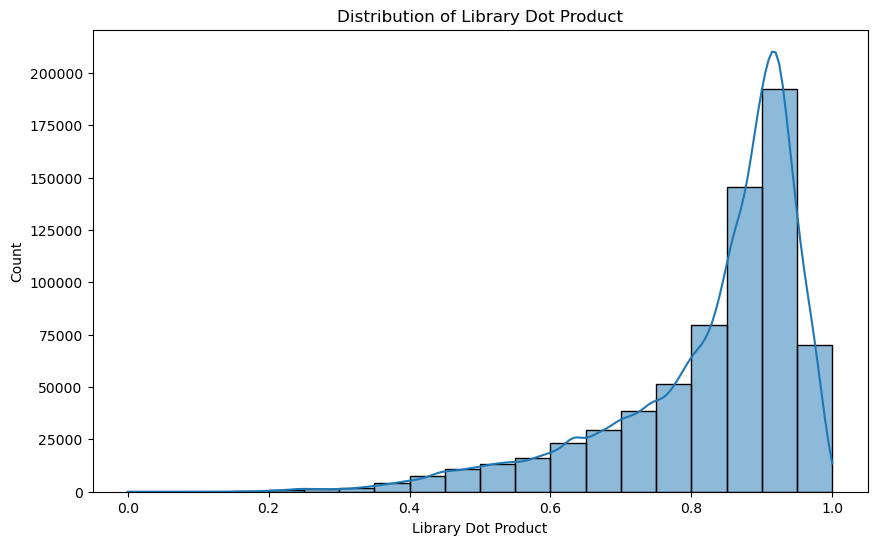

In [9]:
kdm.plot_library_dot_product_distribution(skyline_data)

In [10]:
skyline_clean = kdm.filter_library_dot_product(skyline_data, threshold=0.6)


In [11]:
# Summarise each peptide to count how many heavy or light signals are present in skyline_pivot
peptide_counts = kdm.summarise_peptide_counts(skyline_clean)


In [12]:
report_summary, peptide_list = kdm.report_peptide_protein_summary(peptide_counts)

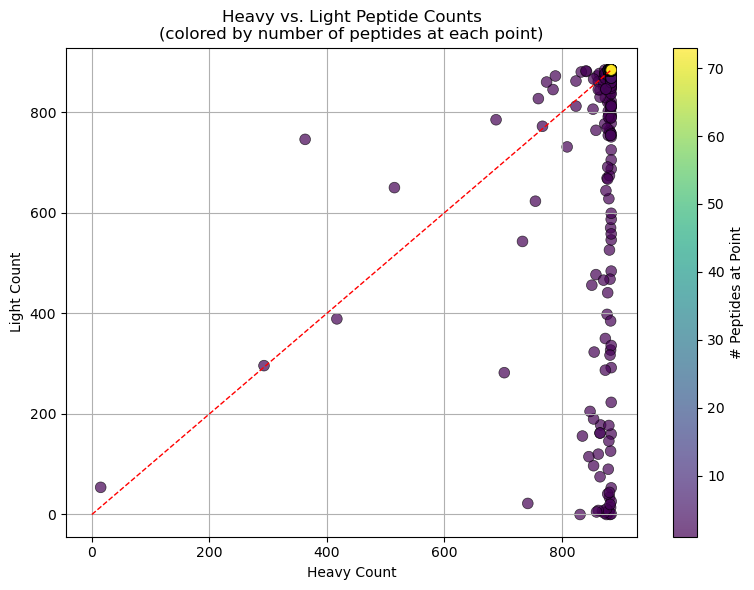

In [13]:
kdm.plot_heavy_light_scatter(peptide_counts)

In [14]:
filtered_peptide_counts = kdm.filter_peptide_counts(peptide_counts, light_cutoff=700, heavy_cutoff=700)

filtered_peptide_counts.head()


,Protein Name,Peptide,heavy_count,light_count
0,QR0140424_CKB|P12277,GTGGVDTAAVGGVFDVSNADR,884,751
1,QR0140840_SERPINA6|P08185,ITQDAQLK,880,879
2,QR0140840_SERPINA6|P08185,MNTVIAALSR,883,883
3,QR0140840_SERPINA6|P08185,WSAGLTSSQVDLYIPK,884,884
4,QR0221144_ADA2|Q9NZK5,DIPIEVCPISNQVLK,884,868


In [15]:
selected_peptides_report, selected_peptides = kdm.report_peptide_protein_summary(filtered_peptide_counts)

In [16]:
# from kardemumma.importer import MergeFiles
skyline_merge_obj = kdm.MergeFiles(skyline_data, sdrf_data_file, selected_peptides)
skyline_merge = skyline_merge_obj.merge_files()


Sample names in Skyline but not in SDRF:
{'PRM_20251128_MarthaReselection_QC_20251216165924.raw', 'PRM_20251128_MarthaReselection_QC_20251128151944.raw', 'PRM_20251128_MarthaReselection_QC_20251209151815.raw', 'PRM_20251128_MarthaReselection_QC_20251210122424.raw', 'PRM_20251128_MarthaReselection_QC_20251209140116.raw', 'PRM_20251128_MarthaReselection_QC_20251209092514.raw', 'PRM_20251128_MarthaReselection_QC_20251209124901.raw', 'PRM_20251128_MarthaReselection_QC_20251208153500.raw', 'PRM_20251128_MarthaReselection_QC_20251201162324.raw', 'PRM_20251128_MarthaReselection_QC_20251202120251.raw', 'PRM_20251128_MarthaReselection_QC_20251209121038.raw', 'PRM_20251128_MarthaReselection_QC_20251213051215.raw', 'PRM_20251128_MarthaReselection_QC_20251215153457.raw', 'PRM_20251128_MarthaReselection_QC.raw', 'PRM_20251128_MarthaReselection_QC_20251211110209.raw', 'PRM_20251128_MarthaReselection_QC_20251224000719.raw', 'PRM_20251128_MarthaReselection_QC_20251221134443.raw', 'PRM_20251128_MarthaR

In [17]:
skyline_pool = skyline_merge_obj.select_pool_data(col_sample='characteristics[Sample]', sample_value='Pool')

Summary of samples per plate:
Plate Plate_1: 5 unique comment[data file] names
Plate Plate_2: 5 unique comment[data file] names
Plate Plate_3: 5 unique comment[data file] names
Plate Plate_4: 5 unique comment[data file] names
Plate Plate_5: 5 unique comment[data file] names
Plate Plate_6: 5 unique comment[data file] names
Plate Plate_7: 5 unique comment[data file] names
Plate Plate_8: 5 unique comment[data file] names
Plate Plate_9: 3 unique comment[data file] names


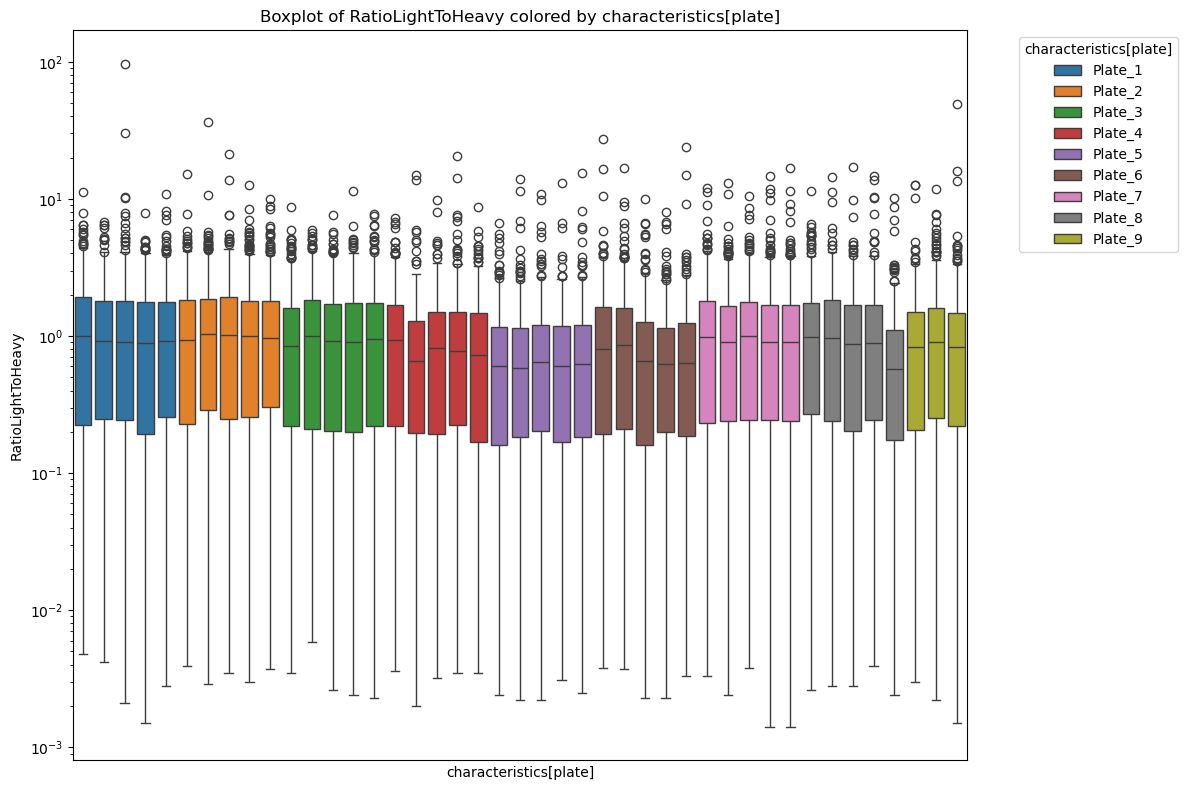

In [18]:
# Plot log_ratio of each sample in boxplot, colored by plate, but x-axis is Replicate, sorted by plate (though x labels are hidden).
kdm.plot_pool_boxplot(skyline_pool)


## Method 1: Per-plate multiplicative conversion factor (prm.py)

Compute intra-/inter-plate CV, select the lowest-CV peptides as a normalization reference set, then fit a single global correction factor per plate (`get_plate_conversion_factors`) and apply it (`adjust_ratio_by_plate`).

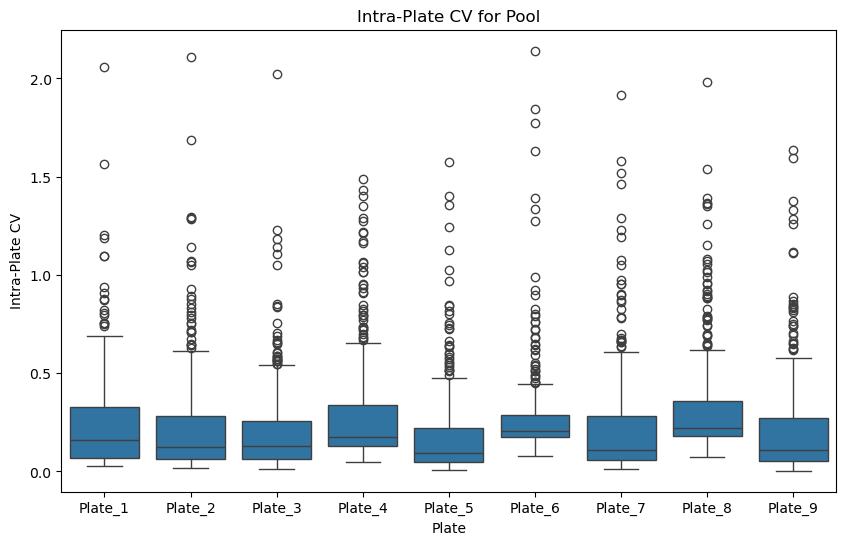

In [19]:
# Calculate intra-plate CV

peptide_plate_stats = kdm.calculate_intra_plate_cv(skyline_pool, col_name='characteristics[plate]')
kdm.plot_intra_plate_cv_stats(peptide_plate_stats, col_name='characteristics[plate]')

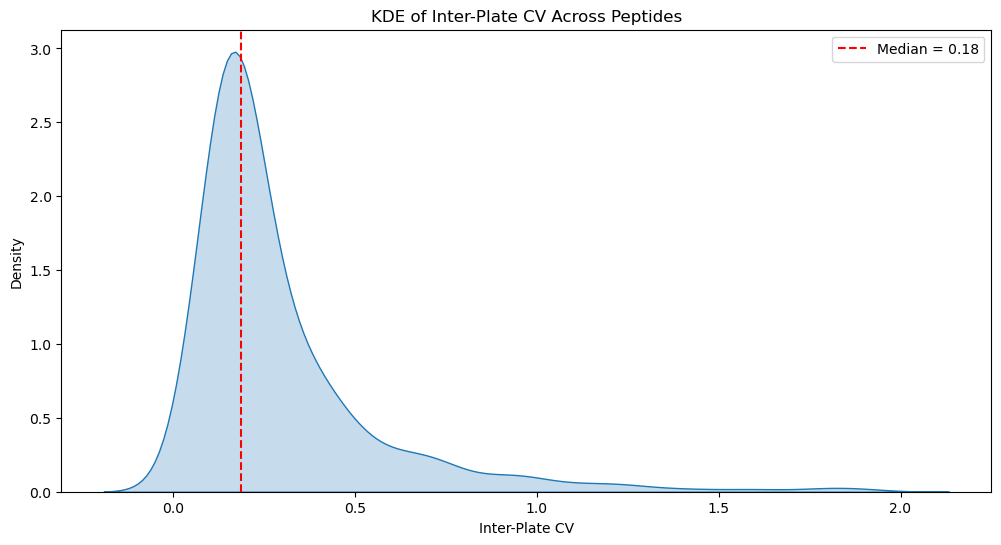

In [20]:
interplate_cv = kdm.calculate_inter_plate_cv(peptide_plate_stats)
kdm.plot_inter_plate_cv_kde(interplate_cv)

In [21]:
interplate_cv.head()

,Peptide Sequence,grand_mean,between_plate_sd,inter_plate_cv
0,LFINVAPHAR,0.038001,0.002403,0.063237
1,SQCTYSNPEGTVVLACDQAQCR,0.912767,0.064558,0.070728
2,VAQVIIPSTYVPGTTNHDIALLR,0.426258,0.030775,0.072199
3,LLDSLPSDTR,1.734461,0.132915,0.076632
4,FSIEGSYQLEK,0.073040,0.006625,0.090706


In [22]:
# Print interplate_cv froom low to high
print('This is the interplate_cv from low to high:')
print(interplate_cv[interplate_cv['inter_plate_cv'] < 0.1])

This is the interplate_cv from low to high:
          Peptide Sequence  grand_mean  between_plate_sd  inter_plate_cv
0               LFINVAPHAR    0.038001          0.002403        0.063237
1   SQCTYSNPEGTVVLACDQAQCR    0.912767          0.064558        0.070728
2  VAQVIIPSTYVPGTTNHDIALLR    0.426258          0.030775        0.072199
3               LLDSLPSDTR    1.734461          0.132915        0.076632
4              FSIEGSYQLEK    0.073040          0.006625        0.090706
5    DVAPGTLCDVAGWGIVNHAGR    0.014163          0.001312        0.092624


Total peptides: 310
  CV < 10%: 6 peptides
  CV < 20%: 172 peptides


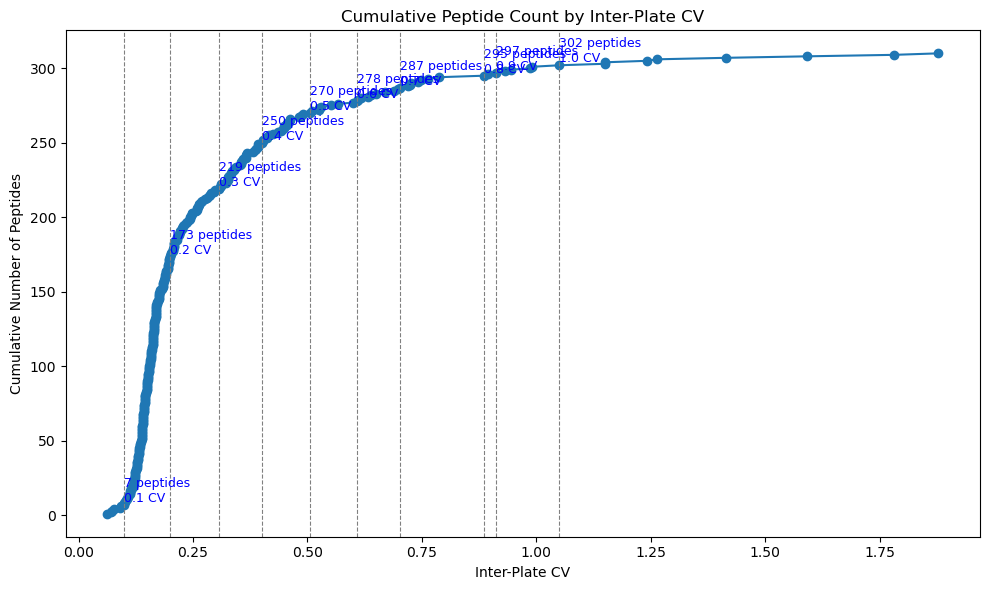

In [23]:
kdm.plot_cumulative_peptide_count_by_cv(interplate_cv)

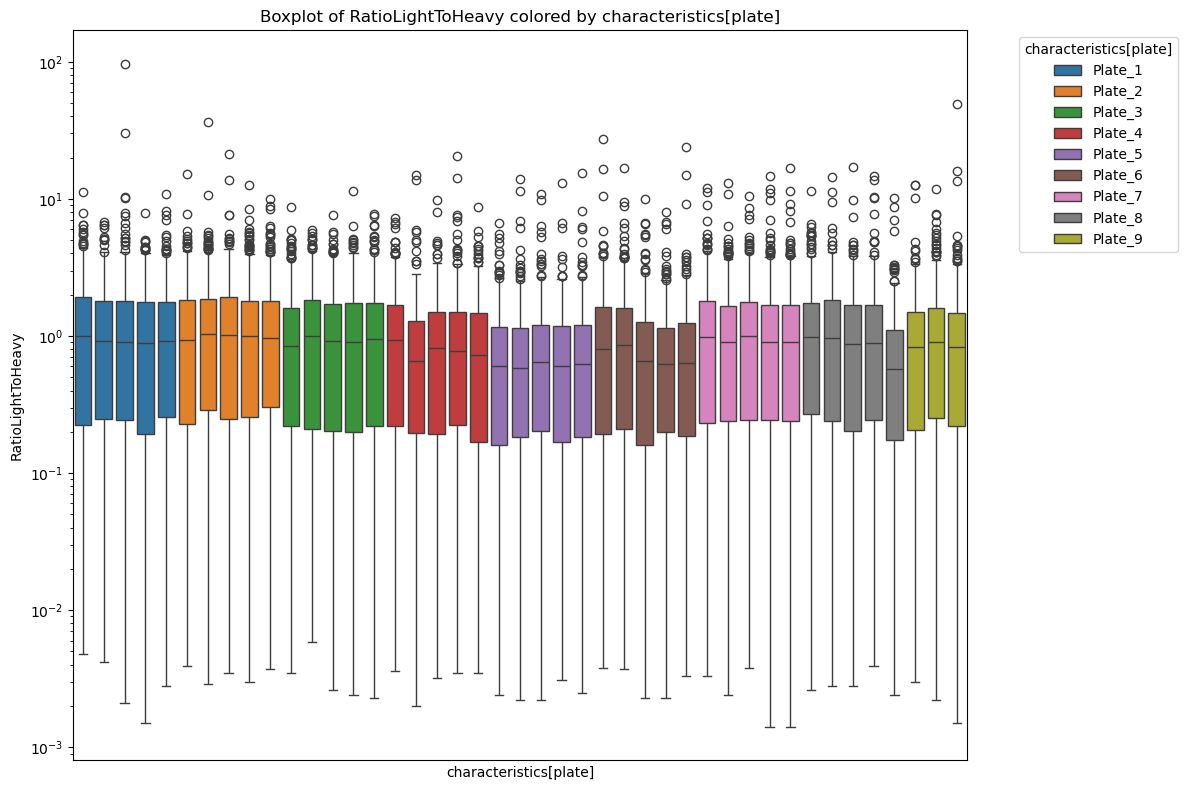

In [24]:
kdm.plot_pool_boxplot(skyline_pool)

In [25]:
selected_peptides = kdm.get_lowest_cv_peptides(interplate_cv, 10)
selected_peptides

array(['LFINVAPHAR', 'SQCTYSNPEGTVVLACDQAQCR', 'VAQVIIPSTYVPGTTNHDIALLR',
       'LLDSLPSDTR', 'FSIEGSYQLEK', 'DVAPGTLCDVAGWGIVNHAGR'], dtype=object)

In [26]:
# Batch/Plate adjustment, correcting for each peptide within each plate (batch) 
# using only peptides in the top 10% lowest inter-plate CV for normalization

pool_selected_df = skyline_pool[skyline_pool['Peptide Sequence'].isin(selected_peptides)]
# Filter pool_data to include only those peptides for normalization calculation
pool_selected_df

,Precursor,Replicate,File Name,Peptide Retention Time,Retention Time Calculator Score,Predicted Retention Time,Peptide Sequence,Peptide,Normalized Area,RatioLightToHeavy,...,characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[96w_pos],characteristics[96w_plate_coordinate],characteristics[LIMS_ID],characteristics[individual],characteristics[biological replicate],factor value[Sample]
72,725.6928+++ (heavy),PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,23.56,101.91,23.78,DVAPGTLCDVAGWGIVNHAGR,DVAPGTLCDVAGWGIVNHAGR,6.2704E+4,0.0207,...,not available,not available,not available,not available,10.0,Plate_1_B2,EMPTY-0001,not available,1.0,Pool
73,722.3567+++,PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,23.56,101.91,23.78,DVAPGTLCDVAGWGIVNHAGR,DVAPGTLCDVAGWGIVNHAGR,6.2704E+4,0.0207,...,not available,not available,not available,not available,10.0,Plate_1_B2,EMPTY-0001,not available,1.0,Pool
124,654.8317++ (heavy),PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,19.73,69.34,20.13,FSIEGSYQLEK,FSIEGSYQLEK,9.7787E+4,0.1027,...,not available,not available,not available,not available,10.0,Plate_1_B2,EMPTY-0001,not available,1.0,Pool
125,650.8246++,PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,19.73,69.34,20.13,FSIEGSYQLEK,FSIEGSYQLEK,9.7787E+4,0.1027,...,not available,not available,not available,not available,10.0,Plate_1_B2,EMPTY-0001,not available,1.0,Pool
286,383.2252+++ (heavy),PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,18.03,49.05,17.85,LFINVAPHAR,LFINVAPHAR,2.7256E+4,0.0353,...,not available,not available,not available,not available,10.0,Plate_1_B2,EMPTY-0001,not available,1.0,Pool
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26343,558.7984++,PRM_20251218_MarthaReselection_Plate_9_H12,PRM_20251218_MarthaReselection_Plate_9_H12.raw,18.36,48.53,17.79,LLDSLPSDTR,LLDSLPSDTR,3.0527E+7,1.8594,...,not available,not available,not available,not available,96.0,Plate_9_H12,EMPTY-0001,not available,1.0,Pool
26482,852.0380+++ (heavy),PRM_20251218_MarthaReselection_Plate_9_H12,PRM_20251218_MarthaReselection_Plate_9_H12.raw,19.06,59.68,19.05,SQCTYSNPEGTVVLACDQAQCR,SQCTYSNPEGTVVLACDQAQCR,1.2127E+5,0.8888,...,not available,not available,not available,not available,96.0,Plate_9_H12,EMPTY-0001,not available,1.0,Pool
26483,848.7019+++,PRM_20251218_MarthaReselection_Plate_9_H12,PRM_20251218_MarthaReselection_Plate_9_H12.raw,19.06,59.68,19.05,SQCTYSNPEGTVVLACDQAQCR,SQCTYSNPEGTVVLACDQAQCR,1.2127E+5,0.8888,...,not available,not available,not available,not available,96.0,Plate_9_H12,EMPTY-0001,not available,1.0,Pool
26554,830.1314+++ (heavy),PRM_20251218_MarthaReselection_Plate_9_H12,PRM_20251218_MarthaReselection_Plate_9_H12.raw,24.73,107.11,24.37,VAQVIIPSTYVPGTTNHDIALLR,VAQVIIPSTYVPGTTNHDIALLR,1.2385E+5,0.4384,...,not available,not available,not available,not available,96.0,Plate_9_H12,EMPTY-0001,not available,1.0,Pool


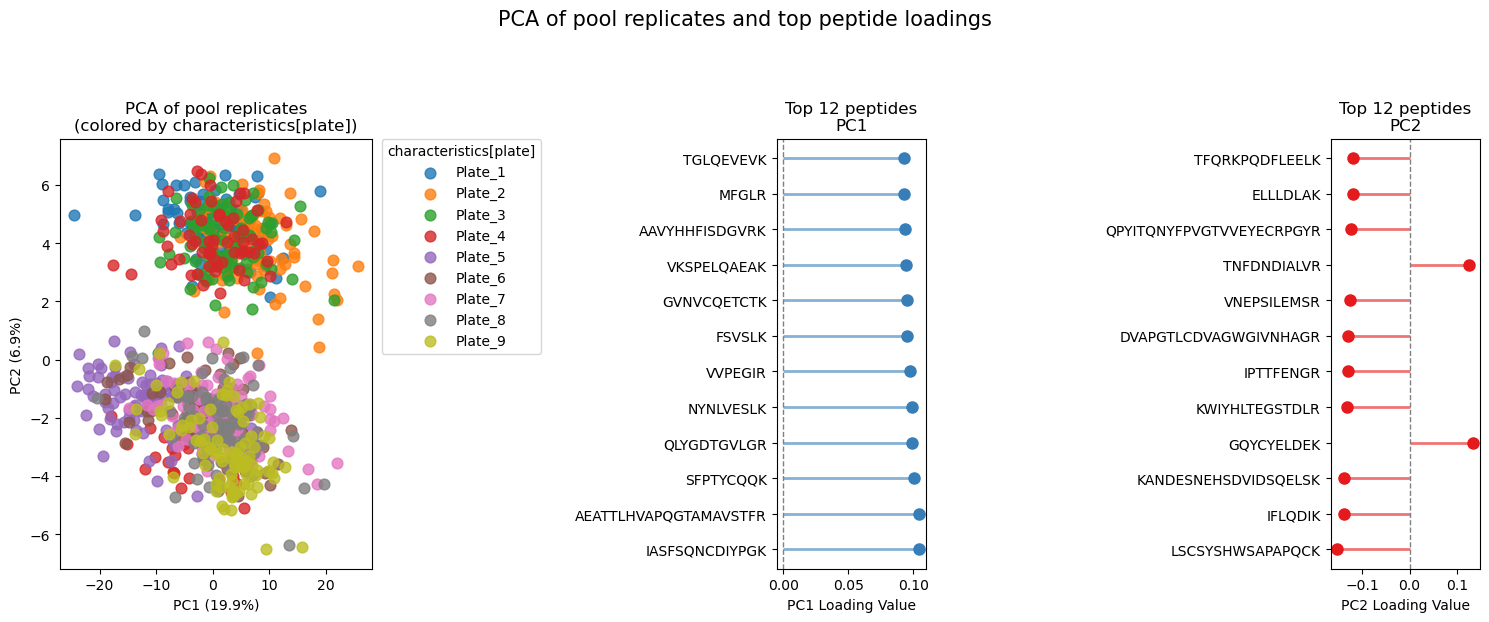

In [27]:
kdm.plot_pool_pca(skyline_merge)

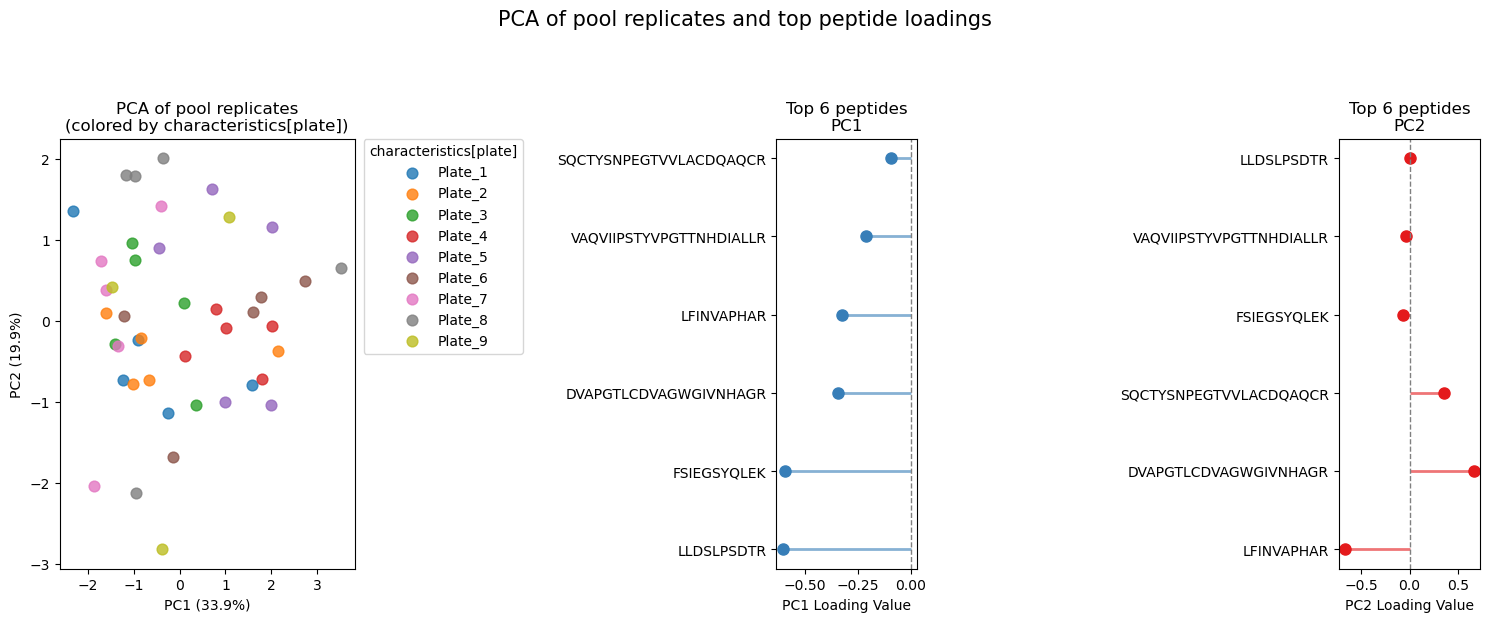

In [28]:
kdm.plot_pool_pca(pool_selected_df)

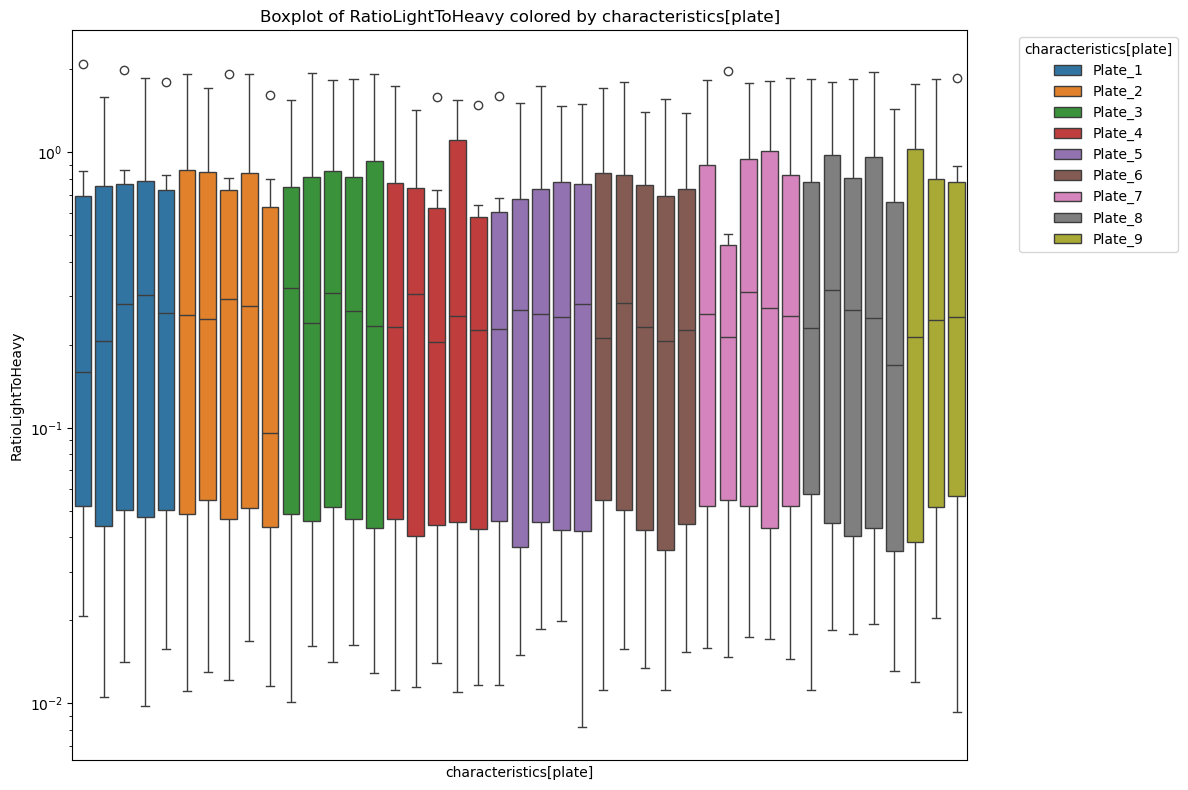

In [29]:
kdm.plot_pool_boxplot(pool_selected_df)

In [30]:
plate_factor_table, conversion_factors, model = kdm.get_plate_conversion_factors(pool_selected_df, col_plate='characteristics[plate]', log_transform=True  )

Conversion factors: {'Plate_1': 1.139586732342153, 'Plate_2': 0.9666251292307191, 'Plate_3': 1.2883263401672571, 'Plate_4': 1.1918600085401956, 'Plate_5': 1.2146416602764194, 'Plate_6': 1.2206011690688392, 'Plate_7': 1.2675002600665493, 'Plate_8': 1.1646016965097268, 'Plate_9': 1.205333504699401}


In [31]:
plate_factor_table

,characteristics[plate],plate_median,correction_factor
0,Plate_1,-1.905369,1.139587
1,Plate_2,-2.246303,0.966625
2,Plate_3,-1.685390,1.288326
3,Plate_4,-1.821802,1.191860
4,Plate_5,-1.787633,1.214642
5,Plate_6,-1.778905,1.220601
6,Plate_7,-1.713083,1.267500
7,Plate_8,-1.864443,1.164602
8,Plate_9,-1.801437,1.205334


In [32]:
conversion_factors

{'Plate_1': 1.139586732342153,
 'Plate_2': 0.9666251292307191,
 'Plate_3': 1.2883263401672571,
 'Plate_4': 1.1918600085401956,
 'Plate_5': 1.2146416602764194,
 'Plate_6': 1.2206011690688392,
 'Plate_7': 1.2675002600665493,
 'Plate_8': 1.1646016965097268,
 'Plate_9': 1.205333504699401}

/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/prm.py:588: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Peptide Sequence"] = pd.Categorical(


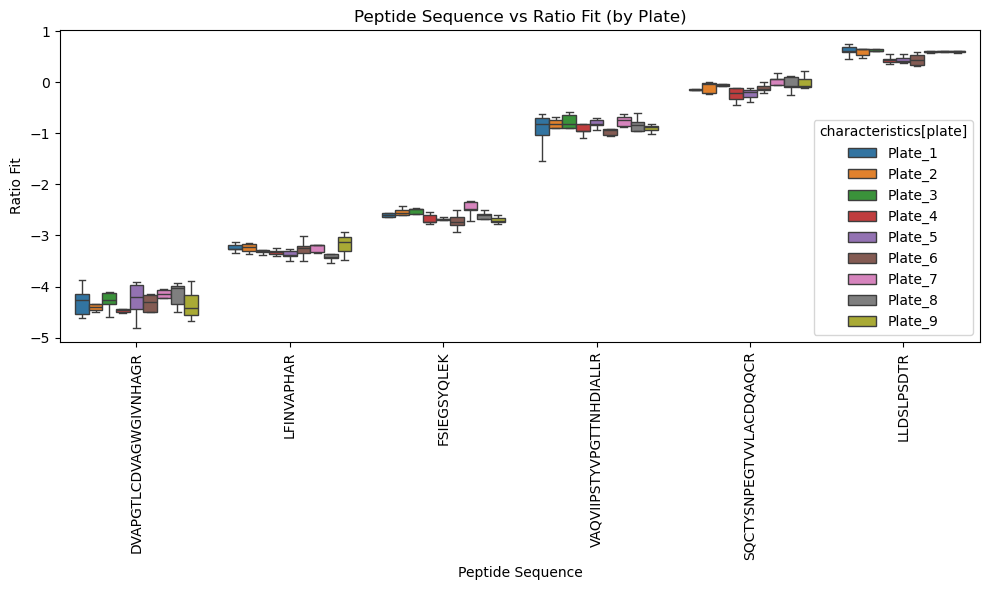

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [33]:
kdm.plot_plate_conversion_factors(pool_selected_df, col_plate='characteristics[plate]', log_transform=True  )

In [34]:
# Use the adjust_ratio_by_plate function above to add RatioLightToHeavy_adj to skyline_merge
# First, construct a Plate column of the correct type for the function
skyline_merge_adj = skyline_merge.copy()
# Remove samples from Replicate column that are in qc_samples
skyline_merge_adj = skyline_merge_adj[~skyline_merge_adj['Replicate'].isin(qc_samples)]

In [35]:
# Adjust ratio by conversion factor 
skyline_merge_adj = kdm.adjust_ratio_by_plate(skyline_merge_adj, conversion_factors)

skyline_merge_adj.head()

,Precursor,Replicate,File Name,Peptide Retention Time,Retention Time Calculator Score,Predicted Retention Time,Peptide Sequence,Peptide,Normalized Area,RatioLightToHeavy,...,characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[96w_pos],characteristics[96w_plate_coordinate],characteristics[LIMS_ID],characteristics[individual],characteristics[biological replicate],factor value[Sample]
2,488.2589++,PRM_20251128_MarthaReselection_Plate_1_F4,PRM_20251128_MarthaReselection_Plate_1_F4.raw,13.87,18.77,14.46,ISASAEELR,ISASAEELR,2.8591E+7,2.100586,...,not available,not available,not available,not available,30.0,Plate_1_F4,MRTH1-0976,not available,1.0,MRTH
3,488.2589++,PRM_20251128_MarthaReselection_Plate_1_B6,PRM_20251128_MarthaReselection_Plate_1_B6.raw,13.97,18.77,14.46,ISASAEELR,ISASAEELR,2.9292E+7,2.081895,...,not available,not available,not available,not available,42.0,Plate_1_B6,MRTH1-0092,not available,1.0,MRTH
4,488.2589++,PRM_20251128_MarthaReselection_Plate_1_A3,PRM_20251128_MarthaReselection_Plate_1_A3.raw,13.93,18.77,14.46,ISASAEELR,ISASAEELR,1.2654E+7,1.237905,...,not available,not available,not available,not available,17.0,Plate_1_A3,MRTH1-1160,not available,1.0,MRTH
5,488.2589++,PRM_20251128_MarthaReselection_Plate_1_G11,PRM_20251128_MarthaReselection_Plate_1_G11.raw,13.93,18.77,14.46,ISASAEELR,ISASAEELR,4.0115E+6,0.678316,...,not available,not available,not available,not available,87.0,Plate_1_G11,MRTH1-0919,not available,1.0,MRTH
6,488.2589++,PRM_20251128_MarthaReselection_Plate_1_B8,PRM_20251128_MarthaReselection_Plate_1_B8.raw,14.04,18.77,14.46,ISASAEELR,ISASAEELR,1.5151E+7,1.257473,...,not available,not available,not available,not available,58.0,Plate_1_B8,MRTH1-0787,not available,1.0,MRTH


In [36]:
# From skyline_merge_adj, filter to pool samples
pool_data_adj = skyline_merge_adj[skyline_merge_adj['characteristics[Sample]'] == 'Pool'].copy()

# Reorder by characteristics[Plate]
pool_data_adj = pool_data_adj.sort_values(by='characteristics[plate]')

pool_data_adj.head()


,Precursor,Replicate,File Name,Peptide Retention Time,Retention Time Calculator Score,Predicted Retention Time,Peptide Sequence,Peptide,Normalized Area,RatioLightToHeavy,...,characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[96w_pos],characteristics[96w_plate_coordinate],characteristics[LIMS_ID],characteristics[individual],characteristics[biological replicate],factor value[Sample]
8,488.2589++,PRM_20251128_MarthaReselection_Plate_1_F12,PRM_20251128_MarthaReselection_Plate_1_F12.raw,14.03,18.77,14.46,ISASAEELR,ISASAEELR,2.1576E+7,1.838122,...,not available,not available,not available,not available,94.0,Plate_1_F12,EMPTY-0001,not available,1.0,Pool
337714,783.3247+++,PRM_20251128_MarthaReselection_Plate_1_D10,PRM_20251128_MarthaReselection_Plate_1_D10.raw,18.74,58.28,18.89,GKFCEIGSDDCYVGDGYSYR,GKFCEIGSDDCYVGDGYSYR,9.3644E+3,0.050018,...,not available,not available,not available,not available,76.0,Plate_1_D10,EMPTY-0001,not available,1.0,Pool
337724,783.3247+++,PRM_20251128_MarthaReselection_Plate_1_G12,PRM_20251128_MarthaReselection_Plate_1_G12.raw,18.17,58.28,18.89,GKFCEIGSDDCYVGDGYSYR,GKFCEIGSDDCYVGDGYSYR,1.7982E+4,0.356708,...,not available,not available,not available,not available,95.0,Plate_1_G12,EMPTY-0001,not available,1.0,Pool
337738,783.3247+++,PRM_20251128_MarthaReselection_Plate_1_H12,PRM_20251128_MarthaReselection_Plate_1_H12.raw,18.22,58.28,18.89,GKFCEIGSDDCYVGDGYSYR,GKFCEIGSDDCYVGDGYSYR,1.9697E+4,0.374346,...,not available,not available,not available,not available,96.0,Plate_1_H12,EMPTY-0001,not available,1.0,Pool
337739,783.3247+++,PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,18.42,58.28,18.89,GKFCEIGSDDCYVGDGYSYR,GKFCEIGSDDCYVGDGYSYR,3.2611E+3,0.172431,...,not available,not available,not available,not available,10.0,Plate_1_B2,EMPTY-0001,not available,1.0,Pool


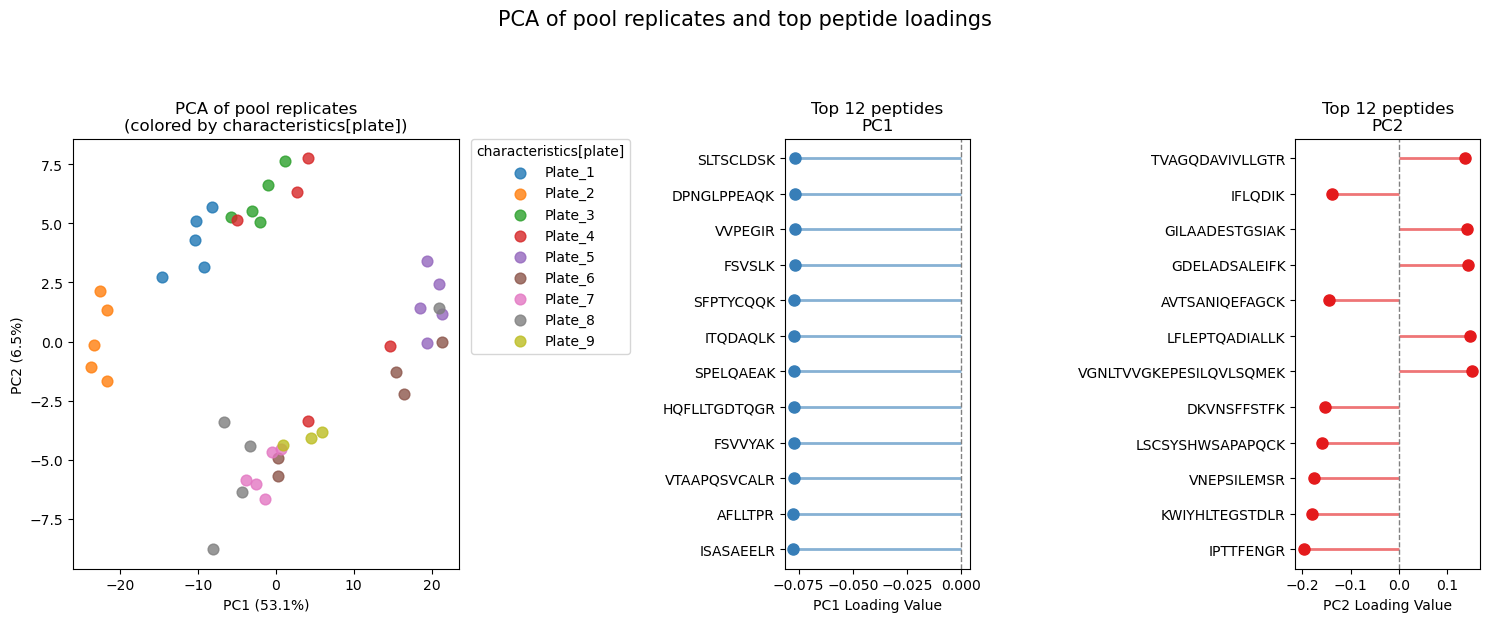

In [37]:
# Show pca of pool data
kdm.plot_pool_pca(pool_data_adj)

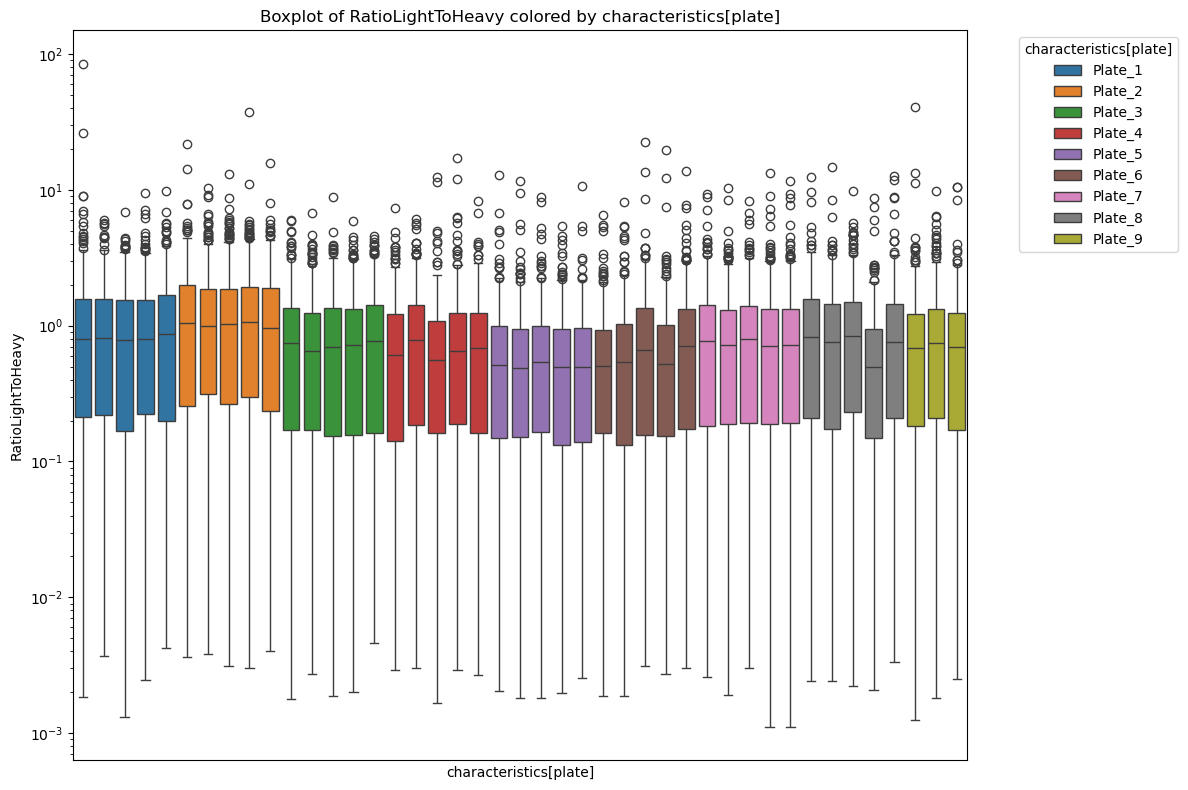

In [38]:
# Show boxplot of pool data
kdm.plot_pool_boxplot(pool_data_adj)

/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/prm.py:588: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Peptide Sequence"] = pd.Categorical(


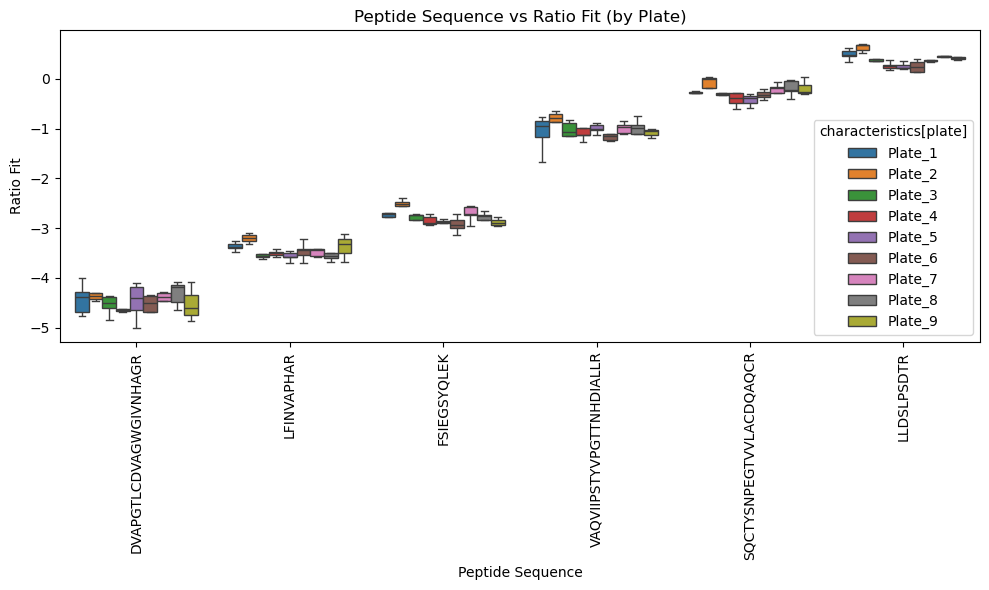

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [39]:
pool_selected_adj = pool_data_adj[pool_data_adj['Peptide Sequence'].isin(selected_peptides)]

kdm.plot_plate_conversion_factors(pool_selected_adj, col_plate='characteristics[plate]', log_transform=True  )

## Method 2: PERMANOVA-driven per-peptide correction (batch_correct.py)

Test every `characteristics[*]` column for batch effects with PERMANOVA, then use `correct_ratio_by_factors` to median-center ratios per peptide for each significant factor (sequentially).

In [40]:
# PERMANOVA test for batch effects across all characteristics columns
permanova_results = kdm.permanova_batch_effects(skyline_pool)

# Suggested factors to correct for (p < 0.05)
sig_factors = permanova_results[permanova_results["p_value"] < 0.05]["variable"].tolist()
print("Suggested factors to correct for batch effect (p < 0.05):", sig_factors)

permanova_results

/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/batch_correct.py:238: RuntimeWarning: invalid value encountered in scalar divide
  ss_within = ss_total - (f_obs * ss_total * (k - 1)) / (f_obs * (k - 1) + (n - k))
/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/batch_correct.py:238: RuntimeWarning: invalid value encountered in scalar divide
  ss_within = ss_total - (f_obs * ss_total * (k - 1)) / (f_obs * (k - 1) + (n - k))



PERMANOVA batch effect summary  (999 permutations)
Significant factors (p < 0.05):  3
  **  characteristics[sample prep batch]
       p = 0.0010  |  F = 10.313  |  R² = 0.201 (medium effect)  |  2 groups, 43 samples
  **  characteristics[plate]
       p = 0.0010  |  F = 3.097  |  R² = 0.422 (large effect)  |  9 groups, 43 samples
  *  characteristics[Column]
       p = 0.0340  |  F = 1.448  |  R² = 0.132 (medium effect)  |  5 groups, 43 samples

Non-significant factors (p >= 0.05):  6
       characteristics[Row]
       p = 0.8290  |  F = 0.844  |  R² = 0.123  |  7 groups, 43 samples
       characteristics[Source Vial]
       p = 0.8880  |  F = 0.898  |  R² = 0.426  |  20 groups, 43 samples
       characteristics[96w_pos]
       p = 0.9340  |  F = 0.868  |  R² = 0.394  |  19 groups, 43 samples
       characteristics[Position]
       p = 0.9520  |  F = 0.868  |  R² = 0.394  |  19 groups, 43 samples
       characteristics[File Name]
       p = 1.0000  |  F = inf  |  R² = nan  |  43 group

,variable,F_statistic,p_value,R2,n_groups,n_samples,n_permutations
0,characteristics[sample prep batch],10.3130,0.001,0.2010,2,43,999
1,characteristics[plate],3.0972,0.001,0.4216,9,43,999
2,characteristics[Column],1.4480,0.034,0.1323,5,43,999
3,characteristics[Row],0.8444,0.829,0.1234,7,43,999
4,characteristics[Source Vial],0.8977,0.888,0.4258,20,43,999
5,characteristics[96w_pos],0.8679,0.934,0.3943,19,43,999
6,characteristics[Position],0.8679,0.952,0.3943,19,43,999
7,characteristics[File Name],inf,1.000,NaN,43,43,999
8,characteristics[96w_plate_coordinate],inf,1.000,NaN,43,43,999
9,characteristics[Sample],NaN,NaN,NaN,1,43,999


In [41]:
# Correct ratios by removing identified batch factors for pool data
skyline_pool_corrected = kdm.correct_ratio_by_factors(
    skyline_pool,
    factors=sig_factors,
    col_ratio="RatioLightToHeavy",
)

# Correct ratio for all data
skyline_corrected = kdm.correct_ratio_by_factors(
    skyline_merge,
    factors=sig_factors,
    col_ratio="RatioLightToHeavy",
)


  Corrected for: characteristics[sample prep batch]
  Corrected for: characteristics[plate]
  Corrected for: characteristics[Column]

Corrected ratios written to 'RatioLightToHeavy_corrected'.
  Corrected for: characteristics[sample prep batch]
  Corrected for: characteristics[plate]
  Corrected for: characteristics[Column]

Corrected ratios written to 'RatioLightToHeavy_corrected'.


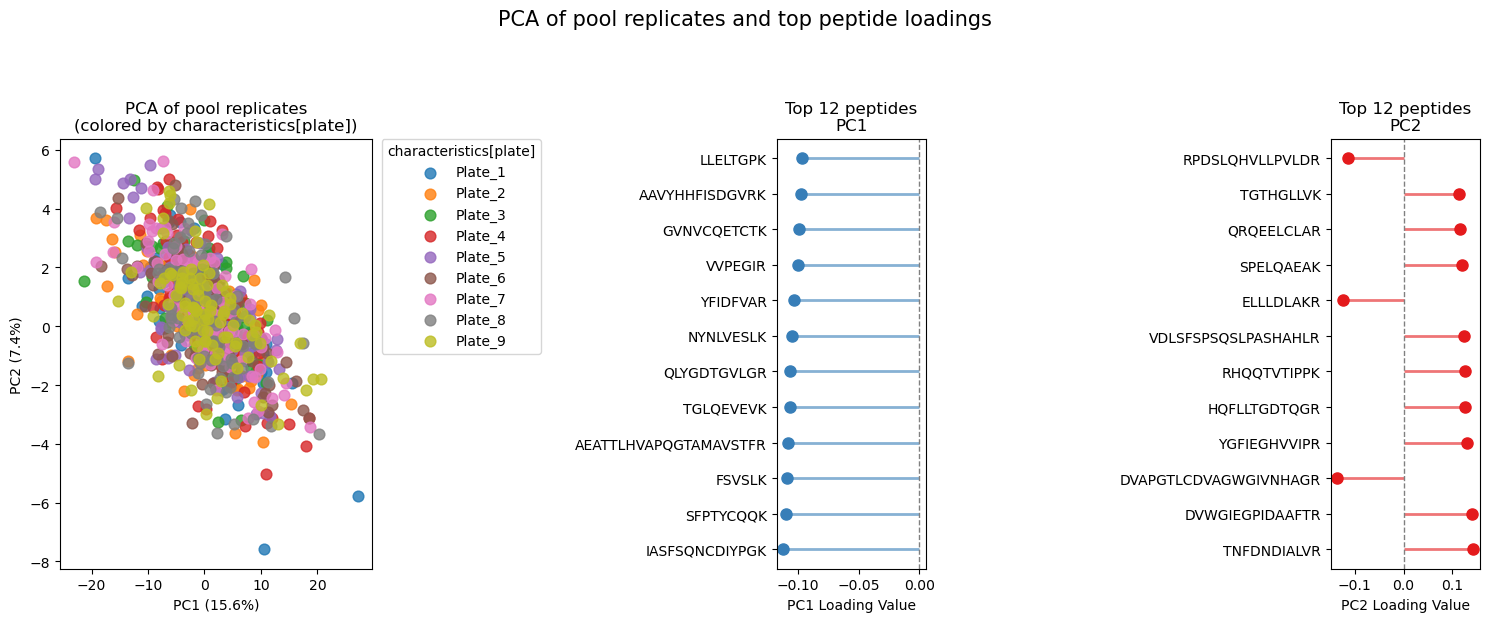

In [42]:
kdm.plot_pool_pca(skyline_corrected, col_ratio="RatioLightToHeavy_corrected")

/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/batch_correct.py:238: RuntimeWarning: invalid value encountered in scalar divide
  ss_within = ss_total - (f_obs * ss_total * (k - 1)) / (f_obs * (k - 1) + (n - k))
/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/batch_correct.py:238: RuntimeWarning: invalid value encountered in scalar divide
  ss_within = ss_total - (f_obs * ss_total * (k - 1)) / (f_obs * (k - 1) + (n - k))



PERMANOVA batch effect summary  (999 permutations)
No significant batch effects detected (all p >= 0.05).

Non-significant factors (p >= 0.05):  9
       characteristics[Row]
       p = 0.5890  |  F = 0.957  |  R² = 0.138  |  7 groups, 43 samples
       characteristics[sample prep batch]
       p = 0.9120  |  F = 0.681  |  R² = 0.016  |  2 groups, 43 samples
       characteristics[96w_pos]
       p = 0.9660  |  F = 0.779  |  R² = 0.369  |  19 groups, 43 samples
       characteristics[Position]
       p = 0.9700  |  F = 0.779  |  R² = 0.369  |  19 groups, 43 samples
       characteristics[Source Vial]
       p = 0.9800  |  F = 0.770  |  R² = 0.389  |  20 groups, 43 samples
       characteristics[Column]
       p = 1.0000  |  F = 0.484  |  R² = 0.049  |  5 groups, 43 samples
       characteristics[plate]
       p = 1.0000  |  F = 0.695  |  R² = 0.141  |  9 groups, 43 samples
       characteristics[File Name]
       p = 1.0000  |  F = inf  |  R² = nan  |  43 groups, 43 samples
       cha

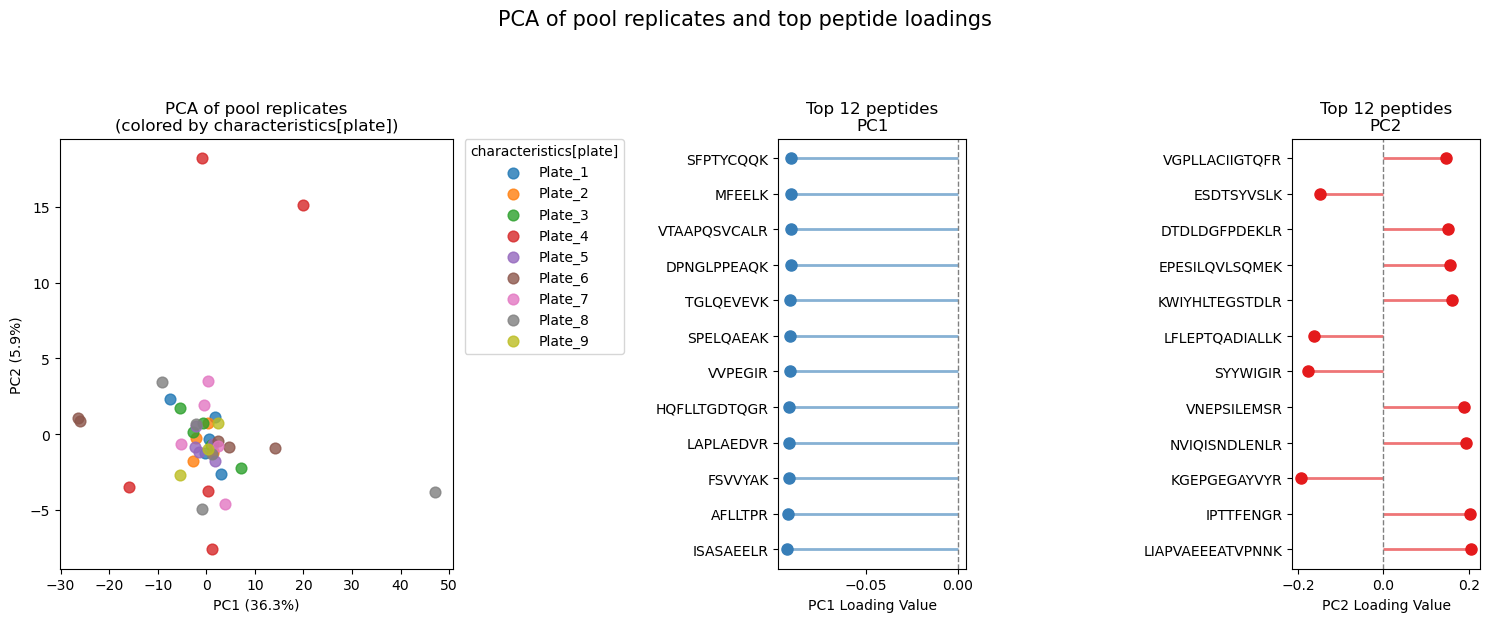

In [43]:
# Verify batch correction — PERMANOVA on corrected ratios
permanova_corrected = kdm.permanova_batch_effects(
    skyline_pool_corrected,
    col_ratio="RatioLightToHeavy_corrected",
)

# Visual check
kdm.plot_pool_pca(skyline_pool_corrected, col_ratio="RatioLightToHeavy_corrected")

## Comparison of the two batch-correction methods

  Corrected for: characteristics[plate]

Corrected ratios written to 'RatioLightToHeavy_corrected'.


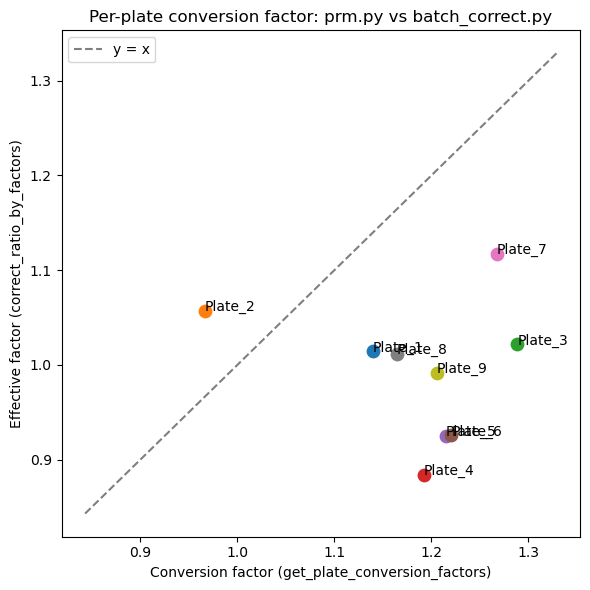

In [44]:
# Compare per-plate conversion factors between the two batch-adjustment approaches:
#   1) get_plate_conversion_factors (prm.py): single global factor per plate
#   2) correct_ratio_by_factors (batch_correct.py): per-peptide correction; aggregated to
#      an effective per-plate factor as median(original / corrected) for a fair comparison.
# Both use the same peptide subset (pool_selected_df) and isolate the plate factor only.

pool_selected_plate_corrected = kdm.correct_ratio_by_factors(
    pool_selected_df,
    factors=['characteristics[plate]'],
    col_ratio="RatioLightToHeavy",
)
pool_selected_plate_corrected['_effective_factor'] = (
    pool_selected_plate_corrected['RatioLightToHeavy']
    / pool_selected_plate_corrected['RatioLightToHeavy_corrected']
)
batch_correct_factors = (
    pool_selected_plate_corrected.groupby('characteristics[plate]')['_effective_factor'].median()
)
batch_correct_factors.index = batch_correct_factors.index.astype(str)

prm_factors = pd.Series(conversion_factors, name='prm_factor')

compare_df = pd.DataFrame({
    'prm_conversion_factor': prm_factors,
    'batch_correct_factor': batch_correct_factors,
}).dropna()

fig, ax = plt.subplots(figsize=(6, 6))
for plate, row in compare_df.iterrows():
    ax.scatter(row['prm_conversion_factor'], row['batch_correct_factor'], s=80)
    ax.annotate(plate, (row['prm_conversion_factor'], row['batch_correct_factor']))
lo, hi = compare_df.values.min(), compare_df.values.max()
pad = (hi - lo) * 0.1 or 0.1
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', alpha=0.5, label='y = x')
ax.set_xlabel('Conversion factor (get_plate_conversion_factors)')
ax.set_ylabel('Effective factor (correct_ratio_by_factors)')
ax.set_title('Per-plate conversion factor: prm.py vs batch_correct.py')
ax.legend()
plt.tight_layout()
plt.show()

# Calculate absolute quantification

In [45]:
# Extract qRePS lot from SDRF file 
qreps_lot = sdrf_data.extract_qreps_lot_number()
# Fetch qRePS table
qreps_table = kdm.fetch_qreps_table(qreps_lot)

qreps_table.head()


qREPs lot number: 24001


,qRePS,Gene,Protein,Uniprot,Amount per well [pmol]
0,QR3140513,A1BG,Alpha-1B-glycoprotein,P04217,1.327
1,QR5000096,A2M,Alpha-2-macroglobulin,P01023,1.971
2,QR0140749,ACTN1,Alpha-actinin-1,P12814,0.157
3,QR0221144,ADA2,Adenosine deaminase 2,Q9NZK5,0.015
4,QR5000237,ADAMTS13,A disintegrin and metalloproteinase with throm...,Q76LX8,0.057


In [46]:
skyline_merge_adj.head()

,Precursor,Replicate,File Name,Peptide Retention Time,Retention Time Calculator Score,Predicted Retention Time,Peptide Sequence,Peptide,Normalized Area,RatioLightToHeavy,...,characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[96w_pos],characteristics[96w_plate_coordinate],characteristics[LIMS_ID],characteristics[individual],characteristics[biological replicate],factor value[Sample]
2,488.2589++,PRM_20251128_MarthaReselection_Plate_1_F4,PRM_20251128_MarthaReselection_Plate_1_F4.raw,13.87,18.77,14.46,ISASAEELR,ISASAEELR,2.8591E+7,2.100586,...,not available,not available,not available,not available,30.0,Plate_1_F4,MRTH1-0976,not available,1.0,MRTH
3,488.2589++,PRM_20251128_MarthaReselection_Plate_1_B6,PRM_20251128_MarthaReselection_Plate_1_B6.raw,13.97,18.77,14.46,ISASAEELR,ISASAEELR,2.9292E+7,2.081895,...,not available,not available,not available,not available,42.0,Plate_1_B6,MRTH1-0092,not available,1.0,MRTH
4,488.2589++,PRM_20251128_MarthaReselection_Plate_1_A3,PRM_20251128_MarthaReselection_Plate_1_A3.raw,13.93,18.77,14.46,ISASAEELR,ISASAEELR,1.2654E+7,1.237905,...,not available,not available,not available,not available,17.0,Plate_1_A3,MRTH1-1160,not available,1.0,MRTH
5,488.2589++,PRM_20251128_MarthaReselection_Plate_1_G11,PRM_20251128_MarthaReselection_Plate_1_G11.raw,13.93,18.77,14.46,ISASAEELR,ISASAEELR,4.0115E+6,0.678316,...,not available,not available,not available,not available,87.0,Plate_1_G11,MRTH1-0919,not available,1.0,MRTH
6,488.2589++,PRM_20251128_MarthaReselection_Plate_1_B8,PRM_20251128_MarthaReselection_Plate_1_B8.raw,14.04,18.77,14.46,ISASAEELR,ISASAEELR,1.5151E+7,1.257473,...,not available,not available,not available,not available,58.0,Plate_1_B8,MRTH1-0787,not available,1.0,MRTH


In [47]:
# Calculate absolute protein concentration
abs_df = kdm.get_absolute_conc(qreps_table, skyline_merge_adj)



Number of unique qRePS ids: 149
Number of unique Peptide Sequences: 310
Number of unique Protein Names: 149
Number of unique Replicates: 861


In [48]:
# Print out the table
abs_df.head()

Replicate                                                  PRM_20251128_MarthaReselection_Plate_1_A1  \
qRePS     Peptide Sequence      Protein Name                                                           
QR0140424 GTGGVDTAAVGGVFDVSNADR QR0140424_CKB|P12277                                          0.0061   
QR0140840 ITQDAQLK              QR0140840_SERPINA6|P08185                                     0.3932   
          MNTVIAALSR            QR0140840_SERPINA6|P08185                                     0.1917   
          WSAGLTSSQVDLYIPK      QR0140840_SERPINA6|P08185                                     0.3956   
QR0221144 DIPIEVCPISNQVLK       QR0221144_ADA2|Q9NZK5                                         0.0077   

Replicate                                                  PRM_20251128_MarthaReselection_Plate_1_A10  \
qRePS     Peptide Sequence      Protein Name                                                            
QR0140424 GTGGVDTAAVGGVFDVSNADR QR0140424_CKB|P12277                                           0.0111   
QR0140840 ITQDAQLK              QR0140840_SERPINA6|P08185                                      0.4473   
          MNTVIAALSR            QR0140840_SERPINA6|P08185                                      0.4038   
          WSAGLTSSQVDLYIPK      QR0140840_SERPINA6|P08185                                      1.4228   
QR0221144 DIPIEVCPISNQVLK       QR0221144_ADA2|Q9NZK5                                          0.0048   

Replicate                                                  PRM_20251128_MarthaReselection_Plate_1_A11  \
qRePS     Peptide Sequence      Protein Name                                                            
QR0140424 GTGGVDTAAVGGVFDVSNADR QR0140424_CKB|P12277                                           0.0083   
QR0140840 ITQDAQLK              QR0140840_SERPINA6|P08185                                      0.5070   
          MNTVIAALSR            QR0140840_SERPINA6|P08185                                      0.3532   
          WSAGLTSSQVDLYIPK      QR0140840_SERPINA6|P08185                                      0.4967   
QR0221144 DIPIEVCPISNQVLK       QR0221144_ADA2|Q9NZK5                                          0.0046   

Replicate                                                  PRM_20251128_MarthaReselection_Plate_1_A12  \
qRePS     Peptide Sequence      Protein Name                                                            
QR0140424 GTGGVDTAAVGGVFDVSNADR QR0140424_CKB|P12277                                           0.0080   
QR0140840 ITQDAQLK              QR0140840_SERPINA6|P08185                                      0.3523   
          MNTVIAALSR            QR0140840_SERPINA6|P08185                                      0.1882   
          WSAGLTSSQVDLYIPK      QR0140840_SERPINA6|P08185                                      0.2868   
QR0221144 DIPIEVCPISNQVLK       QR0221144_ADA2|Q9NZK5                                          0.0024   

Replicate                                                  PRM_20251128_MarthaReselection_Plate_1_A2  \
qRePS     Peptide Sequence      Protein Name                                                           
QR0140424 GTGGVDTAAVGGVFDVSNADR QR0140424_CKB|P12277                                          0.0111   
QR0140840 ITQDAQLK              QR0140840_SERPINA6|P08185                                     0.5024   
          MNTVIAALSR            QR0140840_SERPINA6|P08185                                     0.3249   
          WSAGLTSSQVDLYIPK      QR0140840_SERPINA6|P08185                                     0.4322   
QR0221144 DIPIEVCPISNQVLK       QR0221144_ADA2|Q9NZK5                                         0.0030   

Replicate                                                  PRM_20251128_MarthaReselection_Plate_1_A3  \
qRePS     Peptide Sequence      Protein Name                                                           
QR0140424 GTGGVDTAAVGGVFDVSNADR QR0140424_CKB|P12277                                          0.0244   
QR0140840 ITQDAQLK    

# Downstream analysis

Differential expression and pathway/gene-set enrichment on the absolute peptide concentrations computed above (`abs_df`).

## Differential expression

Compare peptide-level absolute concentrations between two `factor value[Sample]` groups (`MRTH` vs `CHAPS`) with `differential_expression` (Welch's t-test per peptide, Benjamini-Hochberg adjusted).

In [ ]:
# Differential expression between two groups of the SDRF primary variable column
# (defaults to the last 'factor value[...]' column). abs_df is the wide output
# of get_absolute_conc above -- DownStream handles melting/merging with sdrf internally.
de = kdm.DownStream(abs_df, sdrf_data_file, group_a="MRTH", group_b="CHAPS")
de.results.head()

In [ ]:
de.plot_volcano()

## Pathway / gene-set enrichment

Test the significant peptide hits from the differential expression step against pathway/gene-set definitions with a hypergeometric (Fisher's exact) test. Replace the `pathways` placeholder below with a real gene-set database (e.g. Reactome, KEGG, GO) keyed by peptide/protein ID.

In [ ]:
sig_hits = de.results.loc[de.results["padj"] < 0.05, "Peptide Sequence"].tolist()
background = de.results["Peptide Sequence"].tolist()
print(f"{len(sig_hits)} significant peptides (padj < 0.05) out of {len(background)} tested")

# TODO: replace with a real pathway / gene-set database mapping
# pathway name -> list of member peptide/protein IDs drawn from `background`.
pathways = {
    "Example pathway A": background[:5],
    "Example pathway B": background[5:10],
}

if sig_hits:
    enrichment_results = kdm.enrichment_analysis(
        hit_ids=sig_hits,
        pathways=pathways,
        background_ids=background,
        min_overlap=1,
    )
    display(enrichment_results)
else:
    enrichment_results = None
    print("No significant hits at padj < 0.05 -- skip enrichment test.")

In [ ]:
if enrichment_results is not None and not enrichment_results.empty:
    kdm.plot_enrichment(enrichment_results)